<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/NLP/NLP03/NPL03_260907_haena_pjt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 뉴스 요약 프로젝트

뉴스 원문을 입력으로 받아 Attention이 적용된 Seq2Seq 모델을 이용하여
추상적 요약(Abstractive Summarization)을 수행한다.

또한 Summa를 이용한 추출적 요약(Extractive Summarization)을 수행하고
두 결과를 비교한다.

In [2]:
#프로젝트
!pip install -q summa nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
#라이브러리
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from summa.summarizer import summarize

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("사용 장치:", device)

PyTorch: 2.11.0+cu128
사용 장치: cuda


## 1. 데이터 수집

뉴스 원문은 `text`, 실제 요약문은 `headlines` 컬럼을 사용한다.

In [4]:
#데이터 수집
import urllib.request

url = "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv"

urllib.request.urlretrieve(url, "news_summary_more.csv")

data = pd.read_csv(
    "news_summary_more.csv",
    encoding="iso-8859-1"
)

print("데이터 크기:", data.shape)
print("컬럼:", data.columns.tolist())

data.head()

데이터 크기: (98401, 2)
컬럼: ['headlines', 'text']


,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


## 2. 데이터 전처리

뉴스 원문과 요약문의 대소문자를 통일하고 특수문자와 불필요한 공백을 정리하였다.

요약문은 길이가 짧기 때문에 불용어를 모두 제거할 경우 문장의 의미와 구조가
손상될 수 있다고 판단하여 불용어 제거는 적용하지 않았다.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data["text_clean"] = data["text"].apply(clean_text)
data["headlines_clean"] = data["headlines"].apply(clean_text)

data = data[
    (data["text_clean"] != "") &
    (data["headlines_clean"] != "")
].reset_index(drop=True)

print("전처리 후:", data.shape)

data[["text_clean", "headlines_clean"]].head()

전처리 후: (98401, 4)


,text_clean,headlines_clean
0,saurav kant an alumnus of upgrad and iiit b s ...,upgrad learner switches to career in ml al wit...
1,kunal shah s credit card bill payment platform...,delhi techie wins free food from swiggy for on...
2,new zealand defeated india by 8 wickets in the...,new zealand end rohit sharma led india s 12 ma...
3,with aegon life iterm insurance plan customers...,aegon life iterm insurance plan helps customer...
4,speaking about the sexual harassment allegatio...,have known hirani for yrs what if metoo claims...


In [6]:
data["decoder_input"] = data["headlines_clean"].apply(
    lambda x: "sostoken " + x
)

data["decoder_target"] = data["headlines_clean"].apply(
    lambda x: x + " eostoken"
)

data[[
    "headlines_clean",
    "decoder_input",
    "decoder_target"
]].head()

,headlines_clean,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india s 12 ma...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india s 12 ma...
3,aegon life iterm insurance plan helps customer...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


### 데이터셋 분리

전체 데이터를 훈련, 검증, 테스트 데이터로 나누었다.

훈련 데이터는 모델 학습에 사용하고 검증 데이터는 학습 과정의 성능을 확인하며,테스트 데이터는 최종 요약 결과를 확인하는 데 사용한다.

In [7]:
np.random.seed(42)

idx = np.random.permutation(len(data))

train_end = int(len(data) * 0.8)
val_end = int(len(data) * 0.9)

train_data = data.iloc[idx[:train_end]].reset_index(drop=True)
val_data = data.iloc[idx[train_end:val_end]].reset_index(drop=True)
test_data = data.iloc[idx[val_end:]].reset_index(drop=True)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 78720
Validation: 9840
Test: 9841


### Vocabulary와 정수 인코딩

훈련 데이터에서 단어 빈도를 계산하여 Vocabulary를 구성하였다.

빈도가 높은 단어를 중심으로 Vocabulary 크기를 제한하고,
Vocabulary에 없는 단어는 `<UNK>`로 처리하였다.

In [8]:
def tokenize(text):
    return text.split()


SRC_SIZE = 10000
TAR_SIZE = 4000

src_counter = Counter()

for text in train_data["text_clean"]:
    src_counter.update(tokenize(text))

tar_counter = Counter()

for text in train_data["decoder_target"]:
    tar_counter.update(tokenize(text))


src_vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in src_counter.most_common(SRC_SIZE - 2):
    src_vocab[word] = len(src_vocab)


tar_vocab = {
    "<PAD>": 0,
    "<UNK>": 1,
    "sostoken": 2,
    "eostoken": 3
}

for word, _ in tar_counter.most_common(TAR_SIZE - 4):
    if word not in tar_vocab:
        tar_vocab[word] = len(tar_vocab)


print("Source Vocabulary:", len(src_vocab))
print("Target Vocabulary:", len(tar_vocab))

Source Vocabulary: 10000
Target Vocabulary: 3999


In [9]:
def to_sequence(text, vocab):
    return [
        vocab.get(word, vocab["<UNK>"])
        for word in tokenize(text)
    ]


def make_sequences(df):
    enc = [to_sequence(x, src_vocab) for x in df["text_clean"]]
    dec_in = [to_sequence(x, tar_vocab) for x in df["decoder_input"]]
    dec_out = [to_sequence(x, tar_vocab) for x in df["decoder_target"]]
    return enc, dec_in, dec_out


train_enc, train_dec_in, train_dec_out = make_sequences(train_data)
val_enc, val_dec_in, val_dec_out = make_sequences(val_data)
test_enc, test_dec_in, test_dec_out = make_sequences(test_data)


TEXT_MAX_LEN = 60
SUMMARY_MAX_LEN = 15


def pad_data(sequences, max_len):
    tensors = [
        torch.tensor(x[:max_len], dtype=torch.long)
        for x in sequences
    ]

    return pad_sequence(
        tensors,
        batch_first=True,
        padding_value=0
    )[:, :max_len]


X_train = pad_data(train_enc, TEXT_MAX_LEN)
D_train = pad_data(train_dec_in, SUMMARY_MAX_LEN)
Y_train = pad_data(train_dec_out, SUMMARY_MAX_LEN)

X_val = pad_data(val_enc, TEXT_MAX_LEN)
D_val = pad_data(val_dec_in, SUMMARY_MAX_LEN)
Y_val = pad_data(val_dec_out, SUMMARY_MAX_LEN)

X_test = pad_data(test_enc, TEXT_MAX_LEN)
D_test = pad_data(test_dec_in, SUMMARY_MAX_LEN)
Y_test = pad_data(test_dec_out, SUMMARY_MAX_LEN)

print(X_train.shape)
print(D_train.shape)
print(Y_train.shape)

torch.Size([78720, 60])
torch.Size([78720, 15])
torch.Size([78720, 15])


## 3. Attention Seq2Seq 모델

Encoder와 Decoder에 LSTM을 사용하였다.

Decoder가 요약문을 생성할 때 Encoder의 전체 출력 중 필요한 부분을
선택적으로 참고할 수 있도록 Dot-Product Attention을 적용하였다.

In [10]:
EMBED_DIM = 128
HIDDEN_SIZE = 256
LAYERS = 2


class Encoder(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            EMBED_DIM,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            EMBED_DIM,
            HIDDEN_SIZE,
            num_layers=LAYERS,
            dropout=0.3,
            batch_first=True
        )

    def forward(self, x):
      x = self.embedding(x)
      enc_out, (hidden, cell) = self.lstm(x)
      return enc_out, hidden, cell


class Decoder(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            EMBED_DIM,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            EMBED_DIM,
            HIDDEN_SIZE,
            num_layers=LAYERS,
            dropout=0.3,
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        x = self.embedding(x)
        dec_out, (hidden, cell) = self.lstm(
            x, (hidden, cell)
        )
        return dec_out, hidden, cell


class Attention(nn.Module):

    def forward(self, decoder, encoder):

        score = torch.bmm(
            decoder,
            encoder.transpose(1, 2)
        )

        weight = F.softmax(score, dim=-1)

        return torch.bmm(
            weight,
            encoder
        )


class Seq2Seq(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder(len(src_vocab))
        self.decoder = Decoder(len(tar_vocab))
        self.attention = Attention()

        self.combine = nn.Linear(
            HIDDEN_SIZE * 2,
            HIDDEN_SIZE
        )

        self.fc = nn.Linear(
            HIDDEN_SIZE,
            len(tar_vocab)
        )

    def forward(self, src, dec_in):

        enc_out, hidden, cell = self.encoder(src)

        dec_out, _, _ = self.decoder(
            dec_in,
            hidden,
            cell
        )

        context = self.attention(
            dec_out,
            enc_out
        )

        combined = torch.cat(
            [dec_out, context],
            dim=-1
        )

        combined = torch.tanh(
            self.combine(combined)
        )

        return self.fc(combined)


model = Seq2Seq().to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  )
  (decoder): Decoder(
    (embedding): Embedding(3999, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  )
  (attention): Attention()
  (combine): Linear(in_features=512, out_features=256, bias=True)
  (fc): Linear(in_features=256, out_features=3999, bias=True)
)


In [17]:
# 학습
BATCH_SIZE = 256
EPOCHS = 20

train_loader = DataLoader(
    TensorDataset(X_train, D_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, D_val, Y_val),
    batch_size=BATCH_SIZE
)

criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001
)

train_losses = []
val_losses = []

best_loss = float("inf")
wait = 0
PATIENCE = 2


def run_epoch(loader, training=True):

    model.train() if training else model.eval()

    total = 0

    for src, dec_in, target in loader:

        src = src.to(device)
        dec_in = dec_in.to(device)
        target = target.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            output = model(src, dec_in)

            loss = criterion(
                output.reshape(-1, output.size(-1)),
                target.reshape(-1)
            )

            if training:

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0
                )

                optimizer.step()

        total += loss.item()

    return total / len(loader)


for epoch in range(EPOCHS):

    train_loss = run_epoch(
        train_loader,
        True
    )

    val_loss = run_epoch(
        val_loader,
        False
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_loss:
        best_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1

        if wait >= PATIENCE:
            print("Early stopping")
            break

Epoch 1/20 | Train: 2.7466 | Val: 3.0552
Epoch 2/20 | Train: 2.6172 | Val: 3.0051
Epoch 3/20 | Train: 2.5125 | Val: 2.9729
Epoch 4/20 | Train: 2.4193 | Val: 2.9519
Epoch 5/20 | Train: 2.3360 | Val: 2.9380
Epoch 6/20 | Train: 2.2640 | Val: 2.9308
Epoch 7/20 | Train: 2.1926 | Val: 2.9315
Epoch 8/20 | Train: 2.1314 | Val: 2.9265
Epoch 9/20 | Train: 2.0731 | Val: 2.9258
Epoch 10/20 | Train: 2.0164 | Val: 2.9323
Epoch 11/20 | Train: 1.9651 | Val: 2.9401
Early stopping


### 학습 결과

Training Loss와 Validation Loss의 변화를 그래프로 확인하여
모델의 학습 과정을 확인하였다.

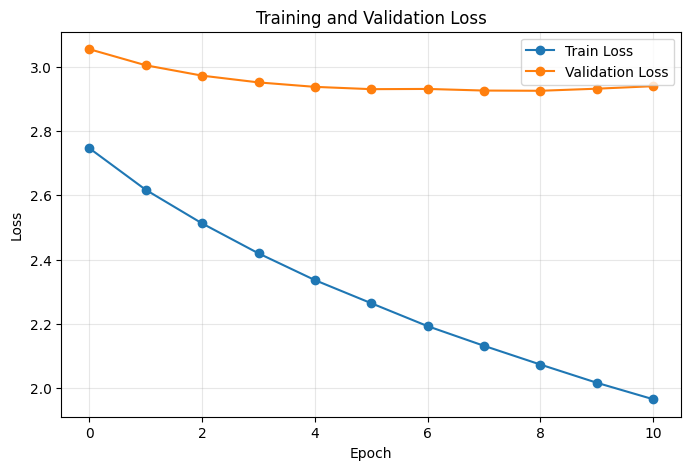

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
# 예측 함수
model.load_state_dict(
    torch.load(
        "best_model.pt",
        map_location=device
    )
)

src_idx_to_word = {
    v: k for k, v in src_vocab.items()
}

tar_idx_to_word = {
    v: k for k, v in tar_vocab.items()
}

SOS = tar_vocab["sostoken"]
EOS = tar_vocab["eostoken"]


def generate_summary(src):

    model.eval()

    src = src.unsqueeze(0).to(device)

    result = []

    with torch.no_grad():

        enc_out, hidden, cell = model.encoder(src)

        current = torch.tensor(
            [[SOS]],
            device=device
        )

        for _ in range(SUMMARY_MAX_LEN):

            dec_out, hidden, cell = model.decoder(
                current,
                hidden,
                cell
            )

            context = model.attention(
                dec_out,
                enc_out
            )

            combined = torch.cat(
                [dec_out, context],
                dim=-1
            )

            combined = torch.tanh(
                model.combine(combined)
            )

            output = model.fc(combined)

            idx = output[:, -1].argmax().item()

            if idx == EOS:
                break

            result.append(
                tar_idx_to_word.get(idx, "<UNK>")
            )

            current = torch.tensor(
                [[idx]],
                device=device
            )

    return " ".join(result)


def restore(sequence, vocab):
    return " ".join(
        vocab.get(int(x), "<UNK>")
        for x in sequence
        if int(x) != 0
    )

## 4. 실제 요약문과 예측 요약 비교

테스트 데이터에서 실제 요약문과 모델이 생성한 추상적 요약문을 비교하였다.

In [20]:
for i in range(10):

    print("=" * 80)

    print(
        "원문:",
        restore(X_test[i], src_idx_to_word)
    )

    print(
        "실제 요약:",
        restore(Y_test[i], tar_idx_to_word)
    )

    print(
        "추상적 요약:",
        generate_summary(X_test[i])
    )

원문: air india has <UNK> rules to take legal action against <UNK> passengers with fines of up to 15 lakh if they delay flights the airline will now fine passengers based on the time by which the flight is delayed it also announced a standard operating procedure to handle <UNK> passengers which includes the immediate filing of an fir
실제 요약: air india to fine <UNK> flyers up to <UNK> for flight delay eostoken
추상적 요약: air india <UNK> rules action against <UNK> passengers
원문: nine years ago on this day banking giant <UNK> brothers filed for bankruptcy after the us government said there would be no bailout however 100 6 400 invested during the end of the 2008 crisis in the s p 500 index would now be nearly 250 16 000 an investor with about 400 000 would have become a millionaire by
실제 요약: 6 400 <UNK> during <UNK> crisis would be 16 000 now eostoken
추상적 요약: <UNK> brothers files for bankruptcy after us govt shutdown
원문: indian cricket team captain virat kohli met women s team members smriti ma

## 5. Summa를 이용한 추출적 요약

Summa를 이용하여 원문에서 중요한 문장을 추출하였다.

추상적 요약 결과와 비교하여 두 방법의 차이를 확인하였다.

In [21]:
def extractive_summary(text):

    try:
        result = summarize(
            text,
            ratio=0.2
        )

        return result.strip()

    except:
        return ""



def get_words(text):
    return set(
        re.findall(r'\b[a-zA-Z0-9]+\b', text.lower())
    )


def keyword_recall(reference, generated):
    ref_words = get_words(reference)
    gen_words = get_words(generated)

    if not ref_words:
        return 0.0

    return len(ref_words & gen_words) / len(ref_words)

In [22]:
# 최종 비교표
results = []

for i in range(10):
    original = test_data.iloc[i]["headlines_clean"]
    abstractive = generate_summary(X_test[i])
    extractive = summarize(test_data.iloc[i]["text_clean"], ratio=0.2)

    results.append({
        "실제 요약": original,
        "Abstractive": abstractive,
        "Extractive": extractive,
        "Abstractive 핵심어 포함률":
            round(keyword_recall(original, abstractive), 3),
        "Extractive 핵심어 포함률":
            round(keyword_recall(original, extractive), 3)
    })

result_df = pd.DataFrame(results)


pd.set_option(
    "display.max_colwidth",
    150
)

result_df

,실제 요약,Abstractive,Extractive,Abstractive 핵심어 포함률,Extractive 핵심어 포함률
0,air india to fine unruly flyers up to 15l for flight delay,air india <UNK> rules action against <UNK> passengers,,0.182,0.0
1,6 400 invested during 2008 crisis would be 16 000 now,<UNK> brothers files for bankruptcy after us govt shutdown,,0.000,0.0
2,virat kohli meets members of indian women s cricket team,kohli meets women s team members after 4th odi vs australia,,0.600,0.0
3,trump undisciplined acts on his instincts former us state secy,trump calls trump <UNK> <UNK> <UNK> <UNK>,,0.100,0.0
4,k taka govt announces loan waiver for 22 lakh small farmers,karnataka govt hikes loan worth 8 <UNK> for farmers,,0.364,0.0
5,swiggy to hire 2 000 women for food delivery by march 2019,swiggy planning to add 2 000 women to <UNK> food delivery,,0.583,0.0
6,sbi s first woman chairman arundhati bhattacharya retires,sbi s first woman chief <UNK> <UNK> <UNK> <UNK> <UNK>,,0.500,0.0
7,ex banker aap member meera sanyal dies from cancer aged 57,<UNK> <UNK> <UNK> <UNK> passes away at 57,,0.091,0.0
8,president clears bill banning hookah bars in gujarat,gujarat bans gujarat <UNK> case of 50 000 jail term,,0.125,0.0
9,mandira shares pic of physical transformation post pregnancy,<UNK> <UNK> apologises for pregnancy after pregnancy,,0.125,0.0


## 6. 결과 분석

추상적 요약은 학습된 단어 관계를 이용하여 원문에 없는 형태의 문장을
생성할 수 있다는 장점이 있다. 반면 학습 정도에 따라 문법적으로
부자연스러운 결과가 나타날 수 있다.

추출적 요약은 원문에 존재하는 문장을 선택하기 때문에 원문의 문법과
정보를 비교적 안정적으로 유지할 수 있다. 그러나 원문에 존재하지 않는
새로운 표현을 생성할 수 없다는 한계가 있다.

실험 결과는 실제 요약문과 생성 결과를 비교하고 핵심어 포함률을 계산하여
두 요약 방법의 특성을 확인하였다.